In [1]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
#Load dataset
df = pd.read_csv("app_user_behavior_dataset.csv")
df.head()

,user_id,age,gender,country,device_type,app_version,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,...,days_since_last_login,subscription_type,ads_clicked_last_30_days,content_downloads,social_shares,rating_given,churn_risk_score,engagement_score,account_age_days,marketing_source
0,100000,56,Female,India,iOS,2.1,5,3.41,52.71,13,...,20,Basic,9,5,2,NaN,0.31,55.79,1152,Referral
1,100001,46,Male,UK,iOS,1.0,8,24.44,42.03,7,...,7,Free,8,3,3,3.0,0.87,82.39,1059,Email Campaign
2,100002,32,Female,UK,iOS,1.2,12,5.34,76.69,7,...,33,Free,11,6,1,2.0,0.63,42.49,678,Google Ads
3,100003,25,Male,India,Android,2.0,5,3.98,65.38,16,...,17,Basic,6,3,1,3.0,0.43,62.81,92,Organic
4,100004,38,Male,Australia,Android,1.0,10,12.85,57.06,13,...,21,Basic,4,4,2,5.0,0.43,38.21,772,Email Campaign


In [3]:
#View the columns in dataset
df.columns

Index(['user_id', 'age', 'gender', 'country', 'device_type', 'app_version',
       'sessions_per_week', 'avg_session_duration_min', 'daily_active_minutes',
       'feature_clicks_per_session', 'notifications_opened_per_week',
       'in_app_search_count', 'pages_viewed_per_session',
       'crash_events_last_30_days', 'support_tickets_raised',
       'days_since_last_login', 'subscription_type',
       'ads_clicked_last_30_days', 'content_downloads', 'social_shares',
       'rating_given', 'churn_risk_score', 'engagement_score',
       'account_age_days', 'marketing_source'],
      dtype='object')

In [4]:
df.shape

(50000, 25)

In [5]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'device_type', 'app_version',
       'sessions_per_week', 'avg_session_duration_min', 'daily_active_minutes',
       'feature_clicks_per_session', 'notifications_opened_per_week',
       'in_app_search_count', 'pages_viewed_per_session',
       'crash_events_last_30_days', 'support_tickets_raised',
       'days_since_last_login', 'subscription_type',
       'ads_clicked_last_30_days', 'content_downloads', 'social_shares',
       'rating_given', 'churn_risk_score', 'engagement_score',
       'account_age_days', 'marketing_source'],
      dtype='object')

In [6]:
#Data understanding
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   user_id                        50000 non-null  int64  
 1   age                            50000 non-null  int64  
 2   gender                         50000 non-null  object 
 3   country                        50000 non-null  object 
 4   device_type                    50000 non-null  object 
 5   app_version                    50000 non-null  float64
 6   sessions_per_week              50000 non-null  int64  
 7   avg_session_duration_min       50000 non-null  float64
 8   daily_active_minutes           50000 non-null  float64
 9   feature_clicks_per_session     50000 non-null  int64  
 10  notifications_opened_per_week  50000 non-null  int64  
 11  in_app_search_count            50000 non-null  int64  
 12  pages_viewed_per_session       50000 non-null 

In [7]:
df.describe() #view statistical summary of dataset

,user_id,age,app_version,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,in_app_search_count,pages_viewed_per_session,crash_events_last_30_days,support_tickets_raised,days_since_last_login,ads_clicked_last_30_days,content_downloads,social_shares,rating_given,churn_risk_score,engagement_score,account_age_days
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,44978.000000,50000.000000,50000.000000,50000.000000
mean,124999.500000,38.513040,1.476126,7.999680,13.149842,45.164537,12.013920,4.99662,3.999060,13.470760,0.397520,0.19666,22.038240,5.995800,3.002260,2.001440,3.630664,0.500834,64.940409,603.785100
std,14433.901067,12.094948,0.470158,2.829438,8.946944,19.505118,3.480289,2.23518,1.997763,6.343635,0.633992,0.44442,12.985237,2.453313,1.731818,1.413435,1.087339,0.288578,14.838827,345.567524
min,100000.000000,18.000000,1.000000,0.000000,0.060000,5.000000,1.000000,0.00000,0.000000,3.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,10.000000,7.000000
25%,112499.750000,28.000000,1.100000,6.000000,6.570000,31.650000,10.000000,3.00000,3.000000,8.000000,0.000000,0.00000,11.000000,4.000000,2.000000,1.000000,3.000000,0.250000,54.900000,302.000000
50%,124999.500000,39.000000,1.200000,8.000000,11.240000,45.210000,12.000000,5.00000,4.000000,13.000000,0.000000,0.00000,22.000000,6.000000,3.000000,2.000000,4.000000,0.500000,65.025000,604.000000
75%,137499.250000,49.000000,2.000000,10.000000,17.570000,58.440000,14.000000,6.00000,5.000000,19.000000,1.000000,0.00000,33.000000,8.000000,4.000000,3.000000,4.000000,0.750000,75.090000,906.000000
max,149999.000000,59.000000,2.100000,26.000000,91.400000,129.130000,28.000000,16.00000,19.000000,24.000000,5.000000,4.00000,44.000000,19.000000,13.000000,11.000000,5.000000,1.000000,100.000000,1199.000000


data cleaning & preprocessing

In [8]:
#Check for duplicate values
df.duplicated().sum() 

np.int64(0)

In [9]:
#Drop duplicates
df.drop_duplicates(inplace = True)

In [10]:
df[df.duplicated()]

,user_id,age,gender,country,device_type,app_version,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,...,days_since_last_login,subscription_type,ads_clicked_last_30_days,content_downloads,social_shares,rating_given,churn_risk_score,engagement_score,account_age_days,marketing_source


In [11]:
#Check for missing values
df.isnull().sum()

user_id                             0
age                                 0
gender                              0
country                             0
device_type                         0
app_version                         0
sessions_per_week                   0
avg_session_duration_min            0
daily_active_minutes                0
feature_clicks_per_session          0
notifications_opened_per_week       0
in_app_search_count                 0
pages_viewed_per_session            0
crash_events_last_30_days           0
support_tickets_raised              0
days_since_last_login               0
subscription_type                   0
ads_clicked_last_30_days            0
content_downloads                   0
social_shares                       0
rating_given                     5022
churn_risk_score                    0
engagement_score                    0
account_age_days                    0
marketing_source                    0
dtype: int64

In [12]:
(df.isnull().sum()/len(df))*100

user_id                           0.000
age                               0.000
gender                            0.000
country                           0.000
device_type                       0.000
app_version                       0.000
sessions_per_week                 0.000
avg_session_duration_min          0.000
daily_active_minutes              0.000
feature_clicks_per_session        0.000
notifications_opened_per_week     0.000
in_app_search_count               0.000
pages_viewed_per_session          0.000
crash_events_last_30_days         0.000
support_tickets_raised            0.000
days_since_last_login             0.000
subscription_type                 0.000
ads_clicked_last_30_days          0.000
content_downloads                 0.000
social_shares                     0.000
rating_given                     10.044
churn_risk_score                  0.000
engagement_score                  0.000
account_age_days                  0.000
marketing_source                  0.000


In [13]:
df.dtypes

user_id                            int64
age                                int64
gender                            object
country                           object
device_type                       object
app_version                      float64
sessions_per_week                  int64
avg_session_duration_min         float64
daily_active_minutes             float64
feature_clicks_per_session         int64
notifications_opened_per_week      int64
in_app_search_count                int64
pages_viewed_per_session           int64
crash_events_last_30_days          int64
support_tickets_raised             int64
days_since_last_login              int64
subscription_type                 object
ads_clicked_last_30_days           int64
content_downloads                  int64
social_shares                      int64
rating_given                     float64
churn_risk_score                 float64
engagement_score                 float64
account_age_days                   int64
marketing_source

In [14]:
#Categorical columns
cat_col = df.select_dtypes(include = ['object','category']).columns
cat_col

Index(['gender', 'country', 'device_type', 'subscription_type',
       'marketing_source'],
      dtype='object')

In [15]:
#Numerical columns
num_col = df.select_dtypes(include = ['int64','float64']).columns
num_col

Index(['user_id', 'age', 'app_version', 'sessions_per_week',
       'avg_session_duration_min', 'daily_active_minutes',
       'feature_clicks_per_session', 'notifications_opened_per_week',
       'in_app_search_count', 'pages_viewed_per_session',
       'crash_events_last_30_days', 'support_tickets_raised',
       'days_since_last_login', 'ads_clicked_last_30_days',
       'content_downloads', 'social_shares', 'rating_given',
       'churn_risk_score', 'engagement_score', 'account_age_days'],
      dtype='object')

In [16]:
#Handling missing values
mean = ['age','app_version','sessions_per_week','daily_active_minutes','notifications_opened_per_week','pages_viewed_per_session','ads_clicked_last_30_days']
median = ['avg_session_duration_min','feature_clicks_per_session','in_app_search_count','crash_events_last_30_days', 'support_tickets_raised','days_since_last_login','content_downloads', 'social_shares', 'rating_given',
       'churn_risk_score', 'engagement_score', 'account_age_days']

#Handling mean, median, mode
for col in mean:
    df[col].fillna(df[col].mean(),inplace = True)
for col in median:
    df[col].fillna(df[col].median(),inplace = True)

In [17]:
#Handling categorical columns
for col in cat_col:
    df[col].fillna(df[col].mode()[0],inplace = True)

In [18]:
cat_col = ['gender', 'country', 'device_type', 'subscription_type',
       'marketing_source']
for col in cat_col:
    print(f"\n {col}")
    print(df[col].astype(str).str.strip().value_counts(dropna= False))


 gender
gender
Female    23994
Male      23936
Other      2070
Name: count, dtype: int64

 country
country
India        22550
USA           9115
UK            5043
Canada        3853
Australia     3498
Germany       3425
Singapore     2516
Name: count, dtype: int64

 device_type
device_type
Android    27315
iOS        17662
Web         5023
Name: count, dtype: int64

 subscription_type
subscription_type
Free       30088
Basic      12495
Premium     7417
Name: count, dtype: int64

 marketing_source
marketing_source
Organic           17539
Google Ads        12468
Referral           7539
Facebook Ads       7463
Email Campaign     4991
Name: count, dtype: int64


In [19]:
#Logical inconsistency
df[(df['age']<18) | (df['age']>60)]

#Handling logical inconsistency: login days should not exceed account age
df['login_issue'] = df['days_since_last_login'] > df['account_age_days']

df.loc[df['login_issue'], 'days_since_last_login'] = df['account_age_days']

In [20]:
#Invalid categorical values
valid_values = {
    'gender' :['male','female','other'],
    'country' :['india','uk','australia','germany','singapore','canada','usa'],
    'device_type' : ['ios','android','web'],
    'subscription_type' : ['free','basic','premium'],
    'marketing_source' : ['organic','google ads','referral','facebook ads','email campaign']}

for col in cat_col:
    df[col] = df[col].astype(str).str.strip().str.lower()

In [21]:
#Check invalids
for col in valid_values:
    df[col] = df[col].astype(str).str.lower().str.strip()

In [22]:
df.describe()

,user_id,age,app_version,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,in_app_search_count,pages_viewed_per_session,crash_events_last_30_days,support_tickets_raised,days_since_last_login,ads_clicked_last_30_days,content_downloads,social_shares,rating_given,churn_risk_score,engagement_score,account_age_days
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,124999.500000,38.513040,1.476126,7.999680,13.149842,45.164537,12.013920,4.99662,3.999060,13.470760,0.397520,0.19666,21.877100,5.995800,3.002260,2.001440,3.667760,0.500834,64.940409,603.785100
std,14433.901067,12.094948,0.470158,2.829438,8.946944,19.505118,3.480289,2.23518,1.997763,6.343635,0.633992,0.44442,12.938953,2.453313,1.731818,1.413435,1.037245,0.288578,14.838827,345.567524
min,100000.000000,18.000000,1.000000,0.000000,0.060000,5.000000,1.000000,0.00000,0.000000,3.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,10.000000,7.000000
25%,112499.750000,28.000000,1.100000,6.000000,6.570000,31.650000,10.000000,3.00000,3.000000,8.000000,0.000000,0.00000,11.000000,4.000000,2.000000,1.000000,3.000000,0.250000,54.900000,302.000000
50%,124999.500000,39.000000,1.200000,8.000000,11.240000,45.210000,12.000000,5.00000,4.000000,13.000000,0.000000,0.00000,22.000000,6.000000,3.000000,2.000000,4.000000,0.500000,65.025000,604.000000
75%,137499.250000,49.000000,2.000000,10.000000,17.570000,58.440000,14.000000,6.00000,5.000000,19.000000,1.000000,0.00000,33.000000,8.000000,4.000000,3.000000,4.000000,0.750000,75.090000,906.000000
max,149999.000000,59.000000,2.100000,26.000000,91.400000,129.130000,28.000000,16.00000,19.000000,24.000000,5.000000,4.00000,44.000000,19.000000,13.000000,11.000000,5.000000,1.000000,100.000000,1199.000000


In [23]:
num_col

Index(['user_id', 'age', 'app_version', 'sessions_per_week',
       'avg_session_duration_min', 'daily_active_minutes',
       'feature_clicks_per_session', 'notifications_opened_per_week',
       'in_app_search_count', 'pages_viewed_per_session',
       'crash_events_last_30_days', 'support_tickets_raised',
       'days_since_last_login', 'ads_clicked_last_30_days',
       'content_downloads', 'social_shares', 'rating_given',
       'churn_risk_score', 'engagement_score', 'account_age_days'],
      dtype='object')

In [24]:
df[num_col].skew()

user_id                          0.000000
age                              0.002237
app_version                      0.382625
sessions_per_week                0.371801
avg_session_duration_min         1.388183
daily_active_minutes             0.102670
feature_clicks_per_session       0.303110
notifications_opened_per_week    0.450539
in_app_search_count              0.522025
pages_viewed_per_session         0.005384
crash_events_last_30_days        1.597267
support_tickets_raised           2.274203
days_since_last_login            0.012338
ads_clicked_last_30_days         0.415973
content_downloads                0.588924
social_shares                    0.692824
rating_given                    -0.804814
churn_risk_score                -0.004397
engagement_score                -0.061145
account_age_days                -0.004607
dtype: float64

In [25]:
skew_df = pd.DataFrame({
    
    'Skewness': df.select_dtypes(include=['number']).skew(numeric_only = True)
})

skew_df.sort_values(by='Skewness', ascending=False)

,Skewness
support_tickets_raised,2.274203
crash_events_last_30_days,1.597267
avg_session_duration_min,1.388183
social_shares,0.692824
content_downloads,0.588924
in_app_search_count,0.522025
notifications_opened_per_week,0.450539
ads_clicked_last_30_days,0.415973
app_version,0.382625
sessions_per_week,0.371801


In [26]:
#Separating high skewed, moderate skewed & approximately normal columns 
for col in df.select_dtypes(include='number').columns:

    skew = df[col].skew()

    if abs(skew) > 1:
        print(col, "-> Highly Skewed")

    elif abs(skew) > 0.5:
        print(col, "-> Moderately Skewed")

    else:
        print(col, "-> Approximately Normal")

user_id -> Approximately Normal
age -> Approximately Normal
app_version -> Approximately Normal
sessions_per_week -> Approximately Normal
avg_session_duration_min -> Highly Skewed
daily_active_minutes -> Approximately Normal
feature_clicks_per_session -> Approximately Normal
notifications_opened_per_week -> Approximately Normal
in_app_search_count -> Moderately Skewed
pages_viewed_per_session -> Approximately Normal
crash_events_last_30_days -> Highly Skewed
support_tickets_raised -> Highly Skewed
days_since_last_login -> Approximately Normal
ads_clicked_last_30_days -> Approximately Normal
content_downloads -> Moderately Skewed
social_shares -> Moderately Skewed
rating_given -> Moderately Skewed
churn_risk_score -> Approximately Normal
engagement_score -> Approximately Normal
account_age_days -> Approximately Normal


In [27]:
#Before handling skewness
high_skew_cols = ['avg_session_duration_min','support_tickets_raised','crash_events_last_30_days']
for col in high_skew_cols:
    print(f"\n {col} :")
    print(df[col].skew())
    


 avg_session_duration_min :
1.388182718813206

 support_tickets_raised :
2.2742028953751916

 crash_events_last_30_days :
1.5972674918331256


In [28]:
#Reducing skewness using log transformation
for col in  high_skew_cols:
    print(f"\n {col} :")
    df[col] = np.log1p(df[col]) 
    print(df[col].skew())


 avg_session_duration_min :
-0.36138532954288916

 support_tickets_raised :
1.8657112985551279

 crash_events_last_30_days :
1.0383428152530028


In [29]:
#Outlier detection & handling using IQR method
outlier = [ 'age', 'app_version', 
          'sessions_per_week',
          'daily_active_minutes',
          'feature_clicks_per_session', 
          'notifications_opened_per_week',
          'in_app_search_count',
          'pages_viewed_per_session',
          'days_since_last_login',
          'ads_clicked_last_30_days',
          'content_downloads',
          'social_shares',
          'rating_given',
          'churn_risk_score',
          'engagement_score', 
          'account_age_days',]
for col in outlier:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    #count_outlier
    outlier_count = ((df[col]<lower) |(df[col]>upper)).sum()

    #cap
    df[col] = np.where(df[col] > upper,upper,df[col])
    df[col] = np.where(df[col] < lower,lower,df[col])

    print(f"{col} → {outlier_count} outliers ({outlier_count/len(df)*100:.2f}%)")

age → 0 outliers (0.00%)
app_version → 0 outliers (0.00%)
sessions_per_week → 181 outliers (0.36%)
daily_active_minutes → 181 outliers (0.36%)
feature_clicks_per_session → 745 outliers (1.49%)
notifications_opened_per_week → 660 outliers (1.32%)
in_app_search_count → 1054 outliers (2.11%)
pages_viewed_per_session → 0 outliers (0.00%)
days_since_last_login → 0 outliers (0.00%)
ads_clicked_last_30_days → 70 outliers (0.14%)
content_downloads → 622 outliers (1.24%)
social_shares → 219 outliers (0.44%)
rating_given → 2518 outliers (5.04%)
churn_risk_score → 0 outliers (0.00%)
engagement_score → 167 outliers (0.33%)
account_age_days → 0 outliers (0.00%)


In [30]:

for col in high_skew_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # capping outliers
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])
    print(f"{col} → {outlier_count} outliers ({outlier_count/len(df)*100:.2f}%)")
print("Outliers handled")

avg_session_duration_min → 0 outliers (0.00%)
support_tickets_raised → 0 outliers (0.00%)
crash_events_last_30_days → 0 outliers (0.00%)
Outliers handled


In [31]:
print('final_missing_value:\n', df.isnull().sum())
print('\n Final_shape:',df.shape)

final_missing_value:
 user_id                          0
age                              0
gender                           0
country                          0
device_type                      0
app_version                      0
sessions_per_week                0
avg_session_duration_min         0
daily_active_minutes             0
feature_clicks_per_session       0
notifications_opened_per_week    0
in_app_search_count              0
pages_viewed_per_session         0
crash_events_last_30_days        0
support_tickets_raised           0
days_since_last_login            0
subscription_type                0
ads_clicked_last_30_days         0
content_downloads                0
social_shares                    0
rating_given                     0
churn_risk_score                 0
engagement_score                 0
account_age_days                 0
marketing_source                 0
login_issue                      0
dtype: int64

 Final_shape: (50000, 26)


In [32]:
#Store the cleaned dataset
clean_data = df.to_csv('app_user_clean.csv', index = False)
print("clean dataset saved successfully")

clean dataset saved successfully


In [ ]:
df= pd.read_csv("app_user_clean.csv")


In [34]:
df.head()

,user_id,age,gender,country,device_type,app_version,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,...,subscription_type,ads_clicked_last_30_days,content_downloads,social_shares,rating_given,churn_risk_score,engagement_score,account_age_days,marketing_source,login_issue
0,100000,56.0,female,india,ios,2.1,5.0,1.483875,52.71,13.0,...,basic,9.0,5.0,2.0,4.0,0.31,55.79,1152.0,referral,False
1,100001,46.0,male,uk,ios,1.0,8.0,3.236323,42.03,7.0,...,free,8.0,3.0,3.0,3.0,0.87,82.39,1059.0,email campaign,False
2,100002,32.0,female,uk,ios,1.2,12.0,1.846879,76.69,7.0,...,free,11.0,6.0,1.0,2.0,0.63,42.49,678.0,google ads,False
3,100003,25.0,male,india,android,2.0,5.0,1.605430,65.38,16.0,...,basic,6.0,3.0,1.0,3.0,0.43,62.81,92.0,organic,False
4,100004,38.0,male,australia,android,1.0,10.0,2.628285,57.06,13.0,...,basic,4.0,4.0,2.0,5.0,0.43,38.21,772.0,email campaign,False


In [35]:
df.isnull().sum()

user_id                          0
age                              0
gender                           0
country                          0
device_type                      0
app_version                      0
sessions_per_week                0
avg_session_duration_min         0
daily_active_minutes             0
feature_clicks_per_session       0
notifications_opened_per_week    0
in_app_search_count              0
pages_viewed_per_session         0
crash_events_last_30_days        0
support_tickets_raised           0
days_since_last_login            0
subscription_type                0
ads_clicked_last_30_days         0
content_downloads                0
social_shares                    0
rating_given                     0
churn_risk_score                 0
engagement_score                 0
account_age_days                 0
marketing_source                 0
login_issue                      0
dtype: int64

In [36]:
df= df.drop(['user_id'],axis = 1)

In [37]:
#Encoding categorical  variables using one-hot encoding
df = pd.get_dummies(df,drop_first=True) 

In [38]:
#View unique values in each column
df.nunique()

age                                42
app_version                         5
sessions_per_week                  17
avg_session_duration_min         4345
daily_active_minutes             8343
feature_clicks_per_session         17
notifications_opened_per_week      12
in_app_search_count                 9
pages_viewed_per_session           22
crash_events_last_30_days           6
support_tickets_raised              5
days_since_last_login              45
ads_clicked_last_30_days           15
content_downloads                   8
social_shares                       7
rating_given                        5
churn_risk_score                  101
engagement_score                 6836
account_age_days                 1193
login_issue                         2
gender_male                         2
gender_other                        2
country_canada                      2
country_germany                     2
country_india                       2
country_singapore                   2
country_uk  

In [39]:
#Remove columns with only one unique values
df = df.loc[:, df.nunique() > 1]

In [40]:
#Feature engineering
df['login_count'] = df['account_age_days'] - df['days_since_last_login']
df['session_time'] = df['avg_session_duration_min'] * df['sessions_per_week']
df['last_login_date'] = pd.to_datetime('today') - pd.to_datetime(df['days_since_last_login'], unit = 'D')
df['app_opens_per_day'] = df['sessions_per_week'] / 7

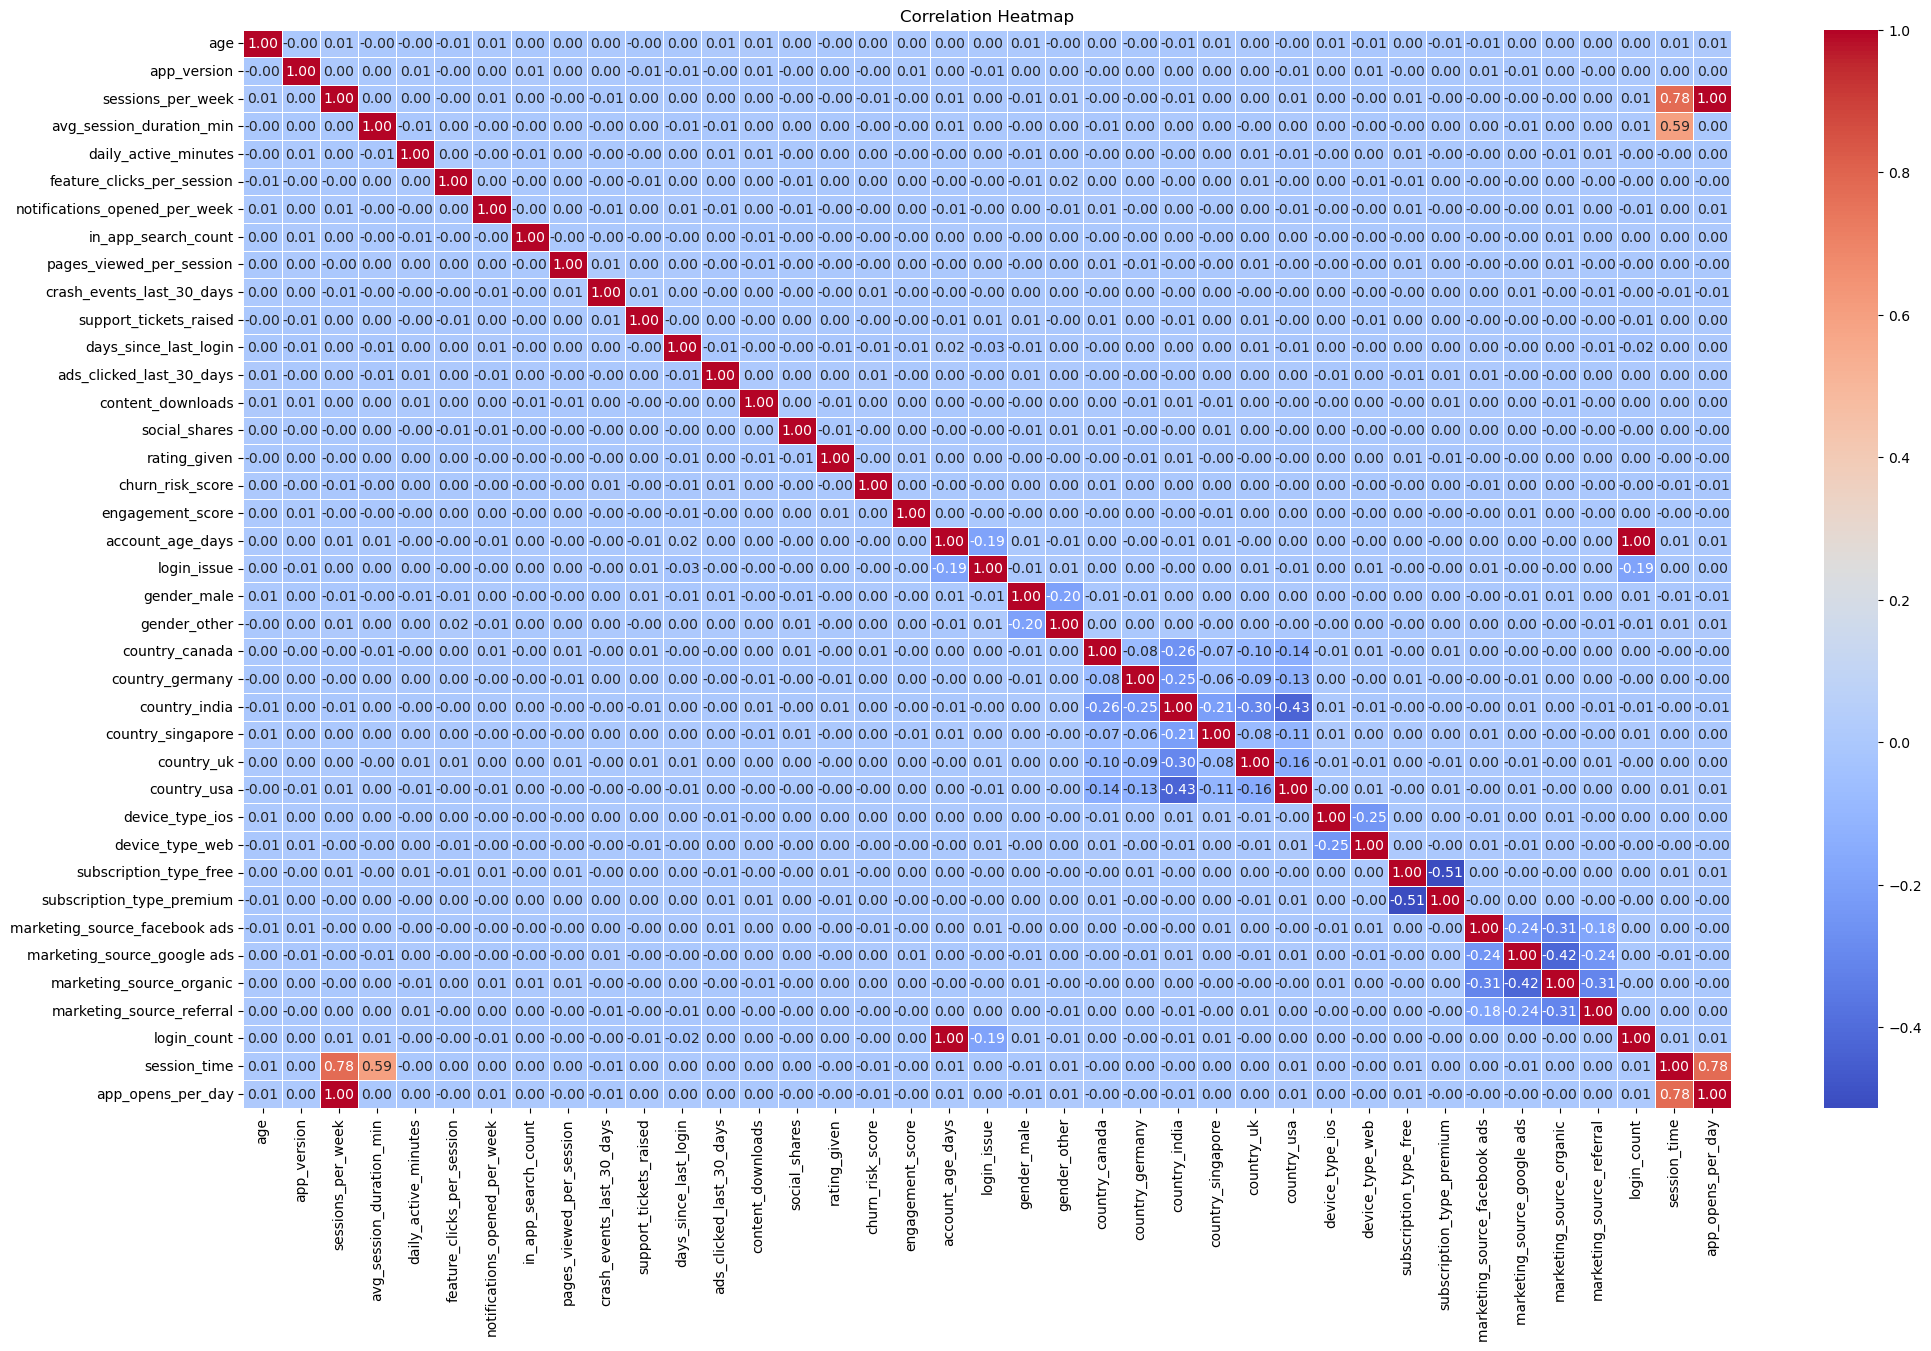

In [41]:
#Correlation heatmap
corr = df.corr(numeric_only = True)
plt.figure(figsize=(24,14))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

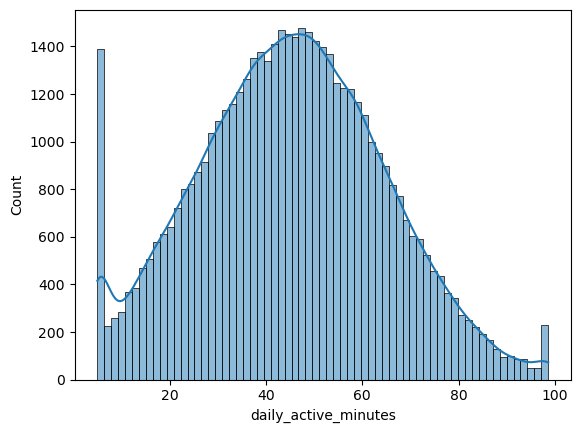

In [42]:
#Distribution of daily active in minutes
sns.histplot(df['daily_active_minutes'],
             kde=True)

plt.show()

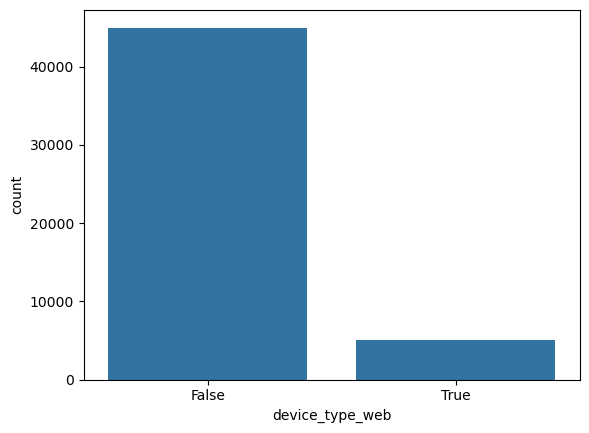

In [43]:
#Distribution of device type web
sns.countplot(x=df['device_type_web'])
plt.show()

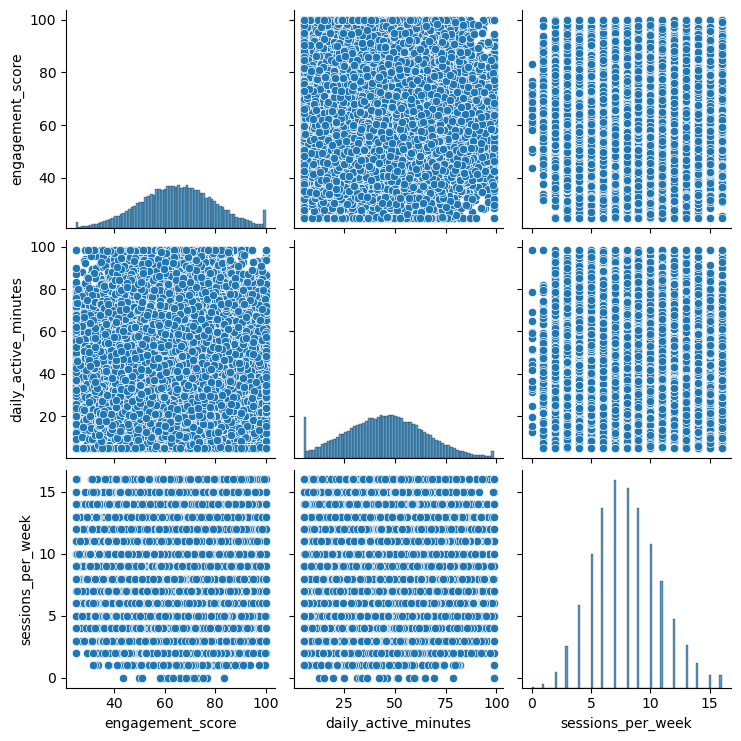

In [44]:
#Pairplot graph
sns.pairplot(df[['engagement_score',
                 'daily_active_minutes',
                 'sessions_per_week']])

plt.show()

In [45]:
df.columns


Index(['age', 'app_version', 'sessions_per_week', 'avg_session_duration_min',
       'daily_active_minutes', 'feature_clicks_per_session',
       'notifications_opened_per_week', 'in_app_search_count',
       'pages_viewed_per_session', 'crash_events_last_30_days',
       'support_tickets_raised', 'days_since_last_login',
       'ads_clicked_last_30_days', 'content_downloads', 'social_shares',
       'rating_given', 'churn_risk_score', 'engagement_score',
       'account_age_days', 'login_issue', 'gender_male', 'gender_other',
       'country_canada', 'country_germany', 'country_india',
       'country_singapore', 'country_uk', 'country_usa', 'device_type_ios',
       'device_type_web', 'subscription_type_free',
       'subscription_type_premium', 'marketing_source_facebook ads',
       'marketing_source_google ads', 'marketing_source_organic',
       'marketing_source_referral', 'login_count', 'session_time',
       'last_login_date', 'app_opens_per_day'],
      dtype='object')

In [46]:
#Feature selection
features = [
       'engagement_score',
        'avg_session_duration_min',
        'sessions_per_week',
        'daily_active_minutes'

]
x = df[features]

In [47]:

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


In [48]:
#Clustering model selection : k means

scaler = StandardScaler()  #feature scaling
X_scaled = scaler.fit_transform(x)

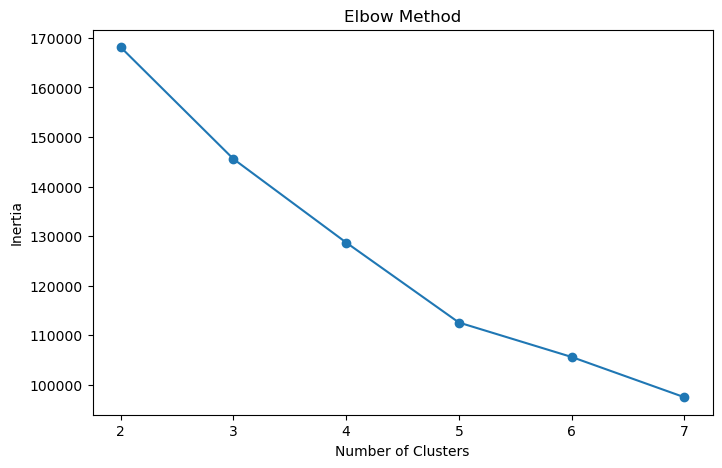

In [49]:
#Elbow method to find optimal k
from sklearn.cluster import MiniBatchKMeans
inertia = []

for k in range(2,8):
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=1000)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
fig, ax = plt.subplots(figsize = (8,5))
plt.plot(range(2,8), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [50]:
from sklearn.utils import resample
sample_size = min(3000,len(df))
x_sample = resample(X_scaled, n_samples = sample_size,random_state = 42)
silhouette_scores = []


In [51]:
#Find best k
for k in range(2,8):
    kmeans = MiniBatchKMeans(n_clusters = k, random_state = 42,batch_size = 1000)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    best_k = silhouette_scores.index(max(silhouette_scores)) + 2
    best_score = max(silhouette_scores)

In [52]:
#Applying k meanswith k = 4
kmeans = MiniBatchKMeans(n_clusters = 4, random_state = 42, batch_size=1000)
df['cluster'] = kmeans.fit_predict(X_scaled)

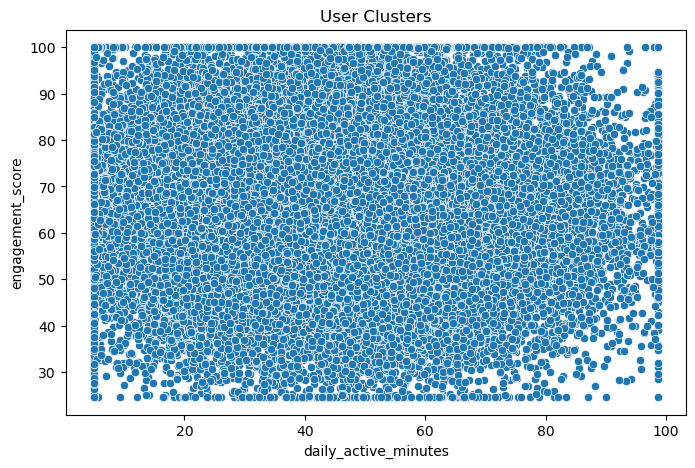

In [53]:
plt.figure(figsize = (8,5))
sns.scatterplot(
    x='daily_active_minutes',
    y='engagement_score',
    data=df,
    palette='Set2'
)

plt.title("User Clusters")
plt.show()

In [54]:
df.groupby('cluster').mean(numeric_only= True)

,age,app_version,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,in_app_search_count,pages_viewed_per_session,crash_events_last_30_days,...,device_type_web,subscription_type_free,subscription_type_premium,marketing_source_facebook ads,marketing_source_google ads,marketing_source_organic,marketing_source_referral,login_count,session_time,app_opens_per_day
cluster,,,,,,,,,,,,,,,,,,,,,
0,38.456353,1.479342,7.771415,2.400602,66.448872,11.984865,4.956680,3.968666,13.544629,0.248527,...,0.101857,0.603862,0.149472,0.149636,0.251820,0.342715,0.156426,580.834574,18.359686,1.110202
1,38.427001,1.476021,5.954285,2.132062,31.932532,11.971075,4.969778,3.980005,13.478822,0.260769,...,0.104404,0.602610,0.148287,0.151568,0.248493,0.352667,0.146073,578.936198,12.231313,0.850612
2,38.614837,1.474846,10.550970,2.794421,35.179651,11.968149,5.012077,3.966265,13.363465,0.251905,...,0.098420,0.599771,0.146647,0.147957,0.245640,0.351674,0.151478,584.856628,28.992140,1.507281
3,38.559345,1.474336,7.847524,2.497983,47.898342,12.036434,4.987401,3.942541,13.494984,0.253809,...,0.096942,0.600754,0.148945,0.147741,0.251505,0.355830,0.149506,583.195891,19.314431,1.121075


In [55]:
df.describe()

,age,app_version,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,in_app_search_count,pages_viewed_per_session,crash_events_last_30_days,...,social_shares,rating_given,churn_risk_score,engagement_score,account_age_days,login_count,session_time,last_login_date,app_opens_per_day,cluster
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000,50000.000000,50000.000000
mean,38.513040,1.476126,7.993120,2.450692,45.142537,11.990020,4.981300,3.96454,13.470760,0.253877,...,1.996100,3.692940,0.500834,64.954722,603.785100,581.908000,19.588709,20581 days 19:04:58.072940032,1.141874,1.498240
std,12.094948,0.470158,2.807795,0.657302,19.438810,3.401375,2.190221,1.90664,6.343635,0.379455,...,1.395494,0.976465,0.288578,14.796437,345.567524,345.540064,8.855426,12 days 22:32:05.536475139,0.401114,1.112377
min,18.000000,1.000000,0.000000,0.058269,5.000000,4.000000,0.000000,0.00000,3.000000,0.000000,...,0.000000,1.500000,0.000000,24.615000,7.000000,0.000000,0.000000,20559 days 16:07:59.512940,0.000000,0.000000
25%,28.000000,1.100000,6.000000,2.024193,31.650000,10.000000,3.000000,3.00000,8.000000,0.000000,...,1.000000,3.000000,0.250000,54.900000,302.000000,280.000000,13.132650,20570 days 16:07:59.512940032,0.857143,1.000000
50%,39.000000,1.200000,8.000000,2.504709,45.210000,12.000000,5.000000,4.00000,13.000000,0.000000,...,2.000000,4.000000,0.500000,65.025000,604.000000,583.000000,18.518589,20581 days 16:07:59.512940032,1.142857,1.000000
75%,49.000000,2.000000,10.000000,2.921547,58.440000,14.000000,6.000000,5.00000,19.000000,0.693147,...,3.000000,4.000000,0.750000,75.090000,906.000000,884.000000,24.968794,20592 days 16:07:59.512940032,1.428571,2.000000
max,59.000000,2.100000,16.000000,4.526127,98.625000,20.000000,10.500000,8.00000,24.000000,1.791759,...,6.000000,5.000000,1.000000,100.000000,1199.000000,1199.000000,66.942088,20603 days 16:07:59.512940,2.285714,3.000000


In [56]:
df['cluster'].value_counts()

cluster
1    13103
3    12461
0    12223
2    12213
Name: count, dtype: int64

In [57]:
df.groupby('cluster')[[
    'daily_active_minutes',
    'sessions_per_week',
    'engagement_score'
]].mean()

,daily_active_minutes,sessions_per_week,engagement_score
cluster,,,
0,66.448872,7.771415,57.280693
1,31.932532,5.954285,60.488566
2,35.179651,10.550970,59.591921
3,47.898342,7.847524,82.434506


In [58]:
cluster_names = {
    0: 'Moderate Users',
    1: 'Occasional Users',
    2: 'At-Risk Users',
    3: 'High Engagement Users'
}
df['cluster_name'] = df['cluster'].map(cluster_names)

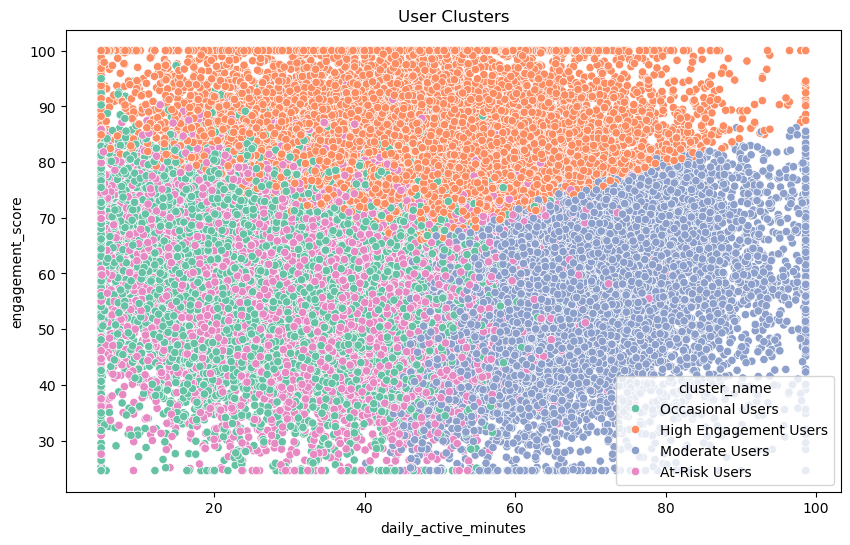

In [59]:
plt.figure(figsize = (10,6))
sns.scatterplot(
    x='daily_active_minutes',
    y='engagement_score',
    hue='cluster_name',
    data=df,
    palette='Set2'
)

plt.title("User Clusters")
plt.show()

In [60]:
#pca
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled)

In [61]:
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

pca_df['cluster_name'] = df['cluster_name']

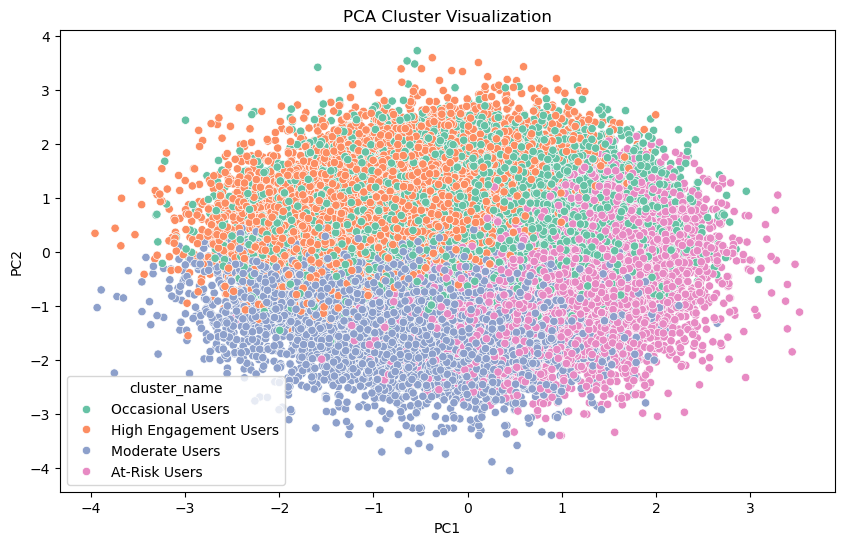

In [62]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='cluster_name',
    data=pca_df,
    palette='Set2'
)

plt.title("PCA Cluster Visualization")
plt.show()

In [63]:
#Cluster level user identification
cluster_profile = df.groupby('cluster').mean(numeric_only=True)

print(cluster_profile)

               age  app_version  sessions_per_week  avg_session_duration_min  \
cluster                                                                        
0        38.456353     1.479342           7.771415                  2.400602   
1        38.427001     1.476021           5.954285                  2.132062   
2        38.614837     1.474846          10.550970                  2.794421   
3        38.559345     1.474336           7.847524                  2.497983   

         daily_active_minutes  feature_clicks_per_session  \
cluster                                                     
0                   66.448872                   11.984865   
1                   31.932532                   11.971075   
2                   35.179651                   11.968149   
3                   47.898342                   12.036434   

         notifications_opened_per_week  in_app_search_count  \
cluster                                                       
0                         